# Genre Classifier
Trains **Logistic Regression**, **SVM**, **Random Forest**, **Naive Bayes**, and **XGBoost** models to classify book genre from 100-word text partitions.

**Inputs required (run the other notebooks first):**
- `partitions.csv` — from `book_partitioner.ipynb`
- `vocabulary.csv` — from `bow.ipynb`

**Outputs:** accuracy scores, classification reports, confusion matrices, and saved model files.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import joblib

## Configuration

In [23]:
PARTITIONS_CSV = "TestingData/partitions.csv"   # output of book_partitioner.ipynb
VOCABULARY_CSV = "FeatureTrainingData/vocabulary.csv"   # output of bow.ipynb

TEST_SIZE      = 0.2    # 80/20 train-test split
RANDOM_STATE   = 42
CV_FOLDS       = 10      # stratified k-fold cross-validation

# Genres in a consistent display order
GENRES = ["biography", "fantasy", "horror", "romance", "sci-fi"]


## Load Data

In [24]:
partitions = pd.read_csv(PARTITIONS_CSV)
vocabulary  = pd.read_csv(VOCABULARY_CSV)["word"].tolist()

print(f"Partitions loaded : {len(partitions):,} rows")
print(f"Vocabulary size   : {len(vocabulary):,} words")
print(f"\nGenre distribution:")
print(partitions['genre'].value_counts().to_string())
partitions.head(3)


Partitions loaded : 5,000 rows
Vocabulary size   : 1,109 words

Genre distribution:
genre
biography    1000
fantasy      1000
horror       1000
romance      1000
sci-fi       1000


,partition_id,book,genre,start_token,text,word_count
0,AutobiographyOfBenjaminFranklin_partition_a,AutobiographyOfBenjaminFranklin,biography,14592,Boston. I took leave of Keimer as going to see...,400
1,AutobiographyOfBenjaminFranklin_partition_b,AutobiographyOfBenjaminFranklin,biography,3278,translated into all the languages of Europe. I...,400
2,AutobiographyOfBenjaminFranklin_partition_c,AutobiographyOfBenjaminFranklin,biography,36048,"in conversation, which makes his company still...",400


## Build Feature Matrix
We use **TF-IDF** restricted to the vocabulary derived from the n-gram analysis.
This ensures the features are exactly the top-100 unigrams we identified per book,
de-duplicated into a shared vocabulary.

In [25]:
X_text = partitions["text"].tolist()
y      = partitions["genre"].tolist()

# TF-IDF restricted to our pre-built vocabulary
vectorizer = TfidfVectorizer(
    vocabulary    = vocabulary,
    sublinear_tf  = True,      # apply log(1+tf) — reduces impact of very frequent words
    strip_accents = 'unicode',
    analyzer      = 'word',
    token_pattern = r'[a-z]+',
    lowercase     = True,
)

X = vectorizer.fit_transform(X_text)
print(f"Feature matrix shape: {X.shape}")
print(f"  {X.shape[0]} partitions  ×  {X.shape[1]} vocabulary features")


Feature matrix shape: (5000, 1109)
  5000 partitions  ×  1109 vocabulary features


## Train / Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,      # preserve genre proportions in both splits
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")


Training samples : 4000
Test samples     : 1000


## Model 1 — Logistic Regression

In [27]:
lr = LogisticRegression(
    max_iter      = 1000,
    random_state  = RANDOM_STATE,
    C             = 1.0,
    solver        = 'lbfgs',
    multi_class   = 'multinomial',
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=" * 50)
print(" Logistic Regression — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=GENRES))


 Logistic Regression — Test Set
Accuracy: 0.8930

              precision    recall  f1-score   support

   biography       0.83      0.91      0.86       200
     fantasy       0.93      0.87      0.90       200
      horror       0.83      0.88      0.85       200
     romance       0.96      0.90      0.93       200
      sci-fi       0.93      0.92      0.93       200

    accuracy                           0.89      1000
   macro avg       0.90      0.89      0.89      1000
weighted avg       0.90      0.89      0.89      1000



## Model 2 — Support Vector Machine

In [28]:
svm = LinearSVC(
    max_iter     = 2000,
    random_state = RANDOM_STATE,
    C            = 1.0,
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("=" * 50)
print(" SVM (LinearSVC) — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print(classification_report(y_test, y_pred_svm, target_names=GENRES))


 SVM (LinearSVC) — Test Set
Accuracy: 0.8910

              precision    recall  f1-score   support

   biography       0.83      0.89      0.86       200
     fantasy       0.92      0.88      0.90       200
      horror       0.84      0.89      0.86       200
     romance       0.93      0.88      0.90       200
      sci-fi       0.94      0.93      0.93       200

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



## Model 3 — Random Forest

In [29]:
rf = RandomForestClassifier(
    n_estimators = 300,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=" * 50)
print(" Random Forest — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=GENRES))

 Random Forest — Test Set
Accuracy: 0.9270

              precision    recall  f1-score   support

   biography       0.90      0.94      0.92       200
     fantasy       0.95      0.89      0.92       200
      horror       0.88      0.94      0.91       200
     romance       0.95      0.91      0.93       200
      sci-fi       0.96      0.96      0.96       200

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



## Model 4 — Naive Bayes (ComplementNB)
ComplementNB is well-suited for text classification with TF-IDF features.

In [30]:
nb = ComplementNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=" * 50)
print(" Naive Bayes (ComplementNB) — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=GENRES))

 Naive Bayes (ComplementNB) — Test Set
Accuracy: 0.7840

              precision    recall  f1-score   support

   biography       0.69      0.84      0.76       200
     fantasy       0.78      0.74      0.76       200
      horror       0.78      0.66      0.71       200
     romance       0.85      0.85      0.85       200
      sci-fi       0.84      0.81      0.83       200

    accuracy                           0.78      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.79      0.78      0.78      1000



## Model 5 — XGBoost
Auto-installs `xgboost` if not present.

In [31]:
try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost'], check=True)
    import xgboost as xgb

from xgb_wrapper import XGBStringClassifier

xgb_clf = XGBStringClassifier(
    n_estimators  = 300,
    max_depth     = 6,
    learning_rate = 0.1,
    random_state  = RANDOM_STATE,
    eval_metric   = 'mlogloss',
    n_jobs        = -1,
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("=" * 50)
print(" XGBoost — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print(classification_report(y_test, y_pred_xgb, target_names=GENRES))

 XGBoost — Test Set
Accuracy: 0.9230

              precision    recall  f1-score   support

   biography       0.89      0.91      0.90       200
     fantasy       0.96      0.91      0.93       200
      horror       0.86      0.94      0.89       200
     romance       0.95      0.92      0.93       200
      sci-fi       0.97      0.95      0.96       200

    accuracy                           0.92      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.93      0.92      0.92      1000



## Model 6 — DistilBERT (Fine-tuned)
Fine-tunes `distilbert-base-uncased` on the 4,000 training partitions for 3 epochs.
DistilBERT uses contextual token embeddings rather than bag-of-words features, so it can exploit word order and sentence structure that TF-IDF ignores.
Mixed-precision training (`fp16`) is enabled automatically when a CUDA GPU is detected.

In [32]:
try:
    import transformers
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'transformers'], check=True)
    import transformers

try:
    import accelerate
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'accelerate>=1.1.0'], check=True)

import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)

# ── GPU check ──────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"fp16 training: ENABLED")
else:
    print("No CUDA GPU detected — training on CPU (will be slower)")
# ──────────────────────────────────────────────────────────────────────────

GENRE2ID = {g: i for i, g in enumerate(GENRES)}
ID2GENRE = {i: g for g, i in GENRE2ID.items()}
BERT_MAX_LEN = 512

# Text-level split — same random state as TF-IDF split so test sets are aligned
texts_train, texts_test, y_train_bert, y_test_bert = train_test_split(
    X_text, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)

labels_train = [GENRE2ID[g] for g in y_train_bert]
labels_test  = [GENRE2ID[g] for g in y_test_bert]

tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class GenreDataset(TorchDataset):
    def __init__(self, texts, labels):
        self.enc    = tokenizer_bert(texts, truncation=True, padding=True, max_length=BERT_MAX_LEN)
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_ds = GenreDataset(texts_train, labels_train)
test_ds  = GenreDataset(texts_test,  labels_test)

model_bert = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels = len(GENRES),
    id2label   = ID2GENRE,
    label2id   = GENRE2ID,
)

def _compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir                  = 'distilbert_checkpoints',
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'no',
    logging_steps               = 50,
    seed                        = RANDOM_STATE,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
)

trainer = Trainer(
    model           = model_bert,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = test_ds,
    compute_metrics = _compute_metrics,
)

trainer.train()
print("\nDistilBERT fine-tuning complete.")

GPU: NVIDIA GeForce RTX 3080  |  VRAM: 10.7 GB
fp16 training: ENABLED


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.147329,0.103913,0.975000
2,0.027070,0.060262,0.984000
3,0.005858,0.049807,0.987000



DistilBERT fine-tuning complete.


In [33]:
preds_output    = trainer.predict(test_ds)
y_pred_ids_bert = np.argmax(preds_output.predictions, axis=-1)
y_pred_bert     = [ID2GENRE[i] for i in y_pred_ids_bert]

print("=" * 50)
print(" DistilBERT (fine-tuned) — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test_bert, y_pred_bert):.4f}\n")
print(classification_report(y_test_bert, y_pred_bert, target_names=GENRES))

 DistilBERT (fine-tuned) — Test Set
Accuracy: 0.9870

              precision    recall  f1-score   support

   biography       0.98      0.98      0.98       200
     fantasy       0.99      1.00      0.99       200
      horror       0.97      0.97      0.97       200
     romance       0.99      0.99      0.99       200
      sci-fi       1.00      0.98      0.99       200

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



## Cross-Validation Comparison
Stratified 10-fold CV across all six models.

- **TF-IDF models (LR, SVM, RF, NB, XGBoost):** the model is fully retrained on each fold's training split, giving a reliable estimate of training variance.
- **DistilBERT:** retraining 10 times would take hours, so its folds are computed by splitting the held-out test set into 10 stratified groups and measuring inference accuracy per group. This shows *prediction variance* rather than training variance, and is shown in a distinct colour.

Logistic Regression        mean=0.8906  std=0.0120  folds=[0.898 0.888 0.896 0.866 0.904 0.89  0.882 0.908 0.896 0.878]
SVM                        mean=0.8946  std=0.0087  folds=[0.894 0.896 0.902 0.886 0.902 0.894 0.88  0.91  0.898 0.884]
Random Forest              mean=0.9326  std=0.0139  folds=[0.936 0.914 0.93  0.942 0.952 0.948 0.914 0.948 0.924 0.918]
Naive Bayes                mean=0.8060  std=0.0224  folds=[0.846 0.8   0.808 0.79  0.774 0.8   0.806 0.848 0.792 0.796]
XGBoost                    mean=0.9308  std=0.0069  folds=[0.932 0.922 0.93  0.926 0.928 0.948 0.932 0.936 0.93  0.924]
DistilBERT*                mean=0.9870  std=0.0090  folds=[0.99 0.99 1.   0.98 0.98 0.99 0.99 0.98 0.97 1.  ]
  * inference folds on test set — model trained once, not per fold


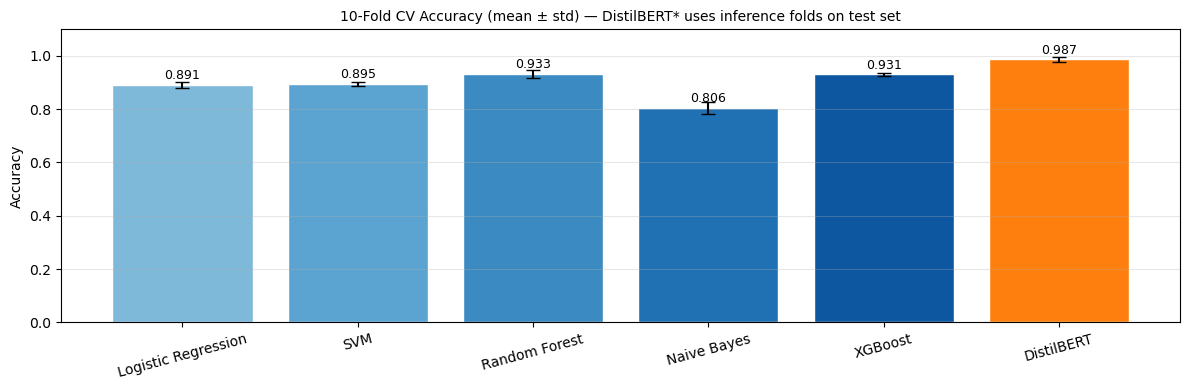

Saved: images/cv_accuracy_per_fold.png


In [34]:
kfold = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

MODELS = {
    'Logistic Regression': lr,
    'SVM':                 svm,
    'Random Forest':       rf,
    'Naive Bayes':         nb,
    'XGBoost':             xgb_clf,
}

cv_results = {}
for name, model in MODELS.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:25}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores, 3)}")

# DistilBERT: 10-fold stratified evaluation on the held-out test set
# The model is trained once; folds measure inference variance, not retraining variance.
bert_kfold  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
y_test_arr  = np.array(y_test_bert)
y_pred_arr  = np.array(y_pred_bert)
bert_scores = np.array([
    accuracy_score(y_test_arr[idx], y_pred_arr[idx])
    for _, idx in bert_kfold.split(y_test_arr, y_test_arr)
])
cv_results['DistilBERT'] = bert_scores
print(f"{'DistilBERT*':25}  mean={bert_scores.mean():.4f}  std={bert_scores.std():.4f}  folds={np.round(bert_scores, 3)}")
print("  * inference folds on test set — model trained once, not per fold")

# Bar chart: TF-IDF models in blue gradient, DistilBERT in orange
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors = list(plt.cm.Blues(np.linspace(0.45, 0.85, len(names) - 1))) + ['#ff7f0e']

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(names, means, yerr=stds, color=colors, edgecolor='white', capsize=5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_title(f'{CV_FOLDS}-Fold CV Accuracy (mean ± std) — DistilBERT* uses inference folds on test set', fontsize=10)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/cv_accuracy_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/cv_accuracy_per_fold.png')

## Confusion Matrices
Each cell shows how many test partitions were assigned to each predicted genre.
Off-diagonal cells are misclassifications — useful for spotting which genres
get confused with each other.

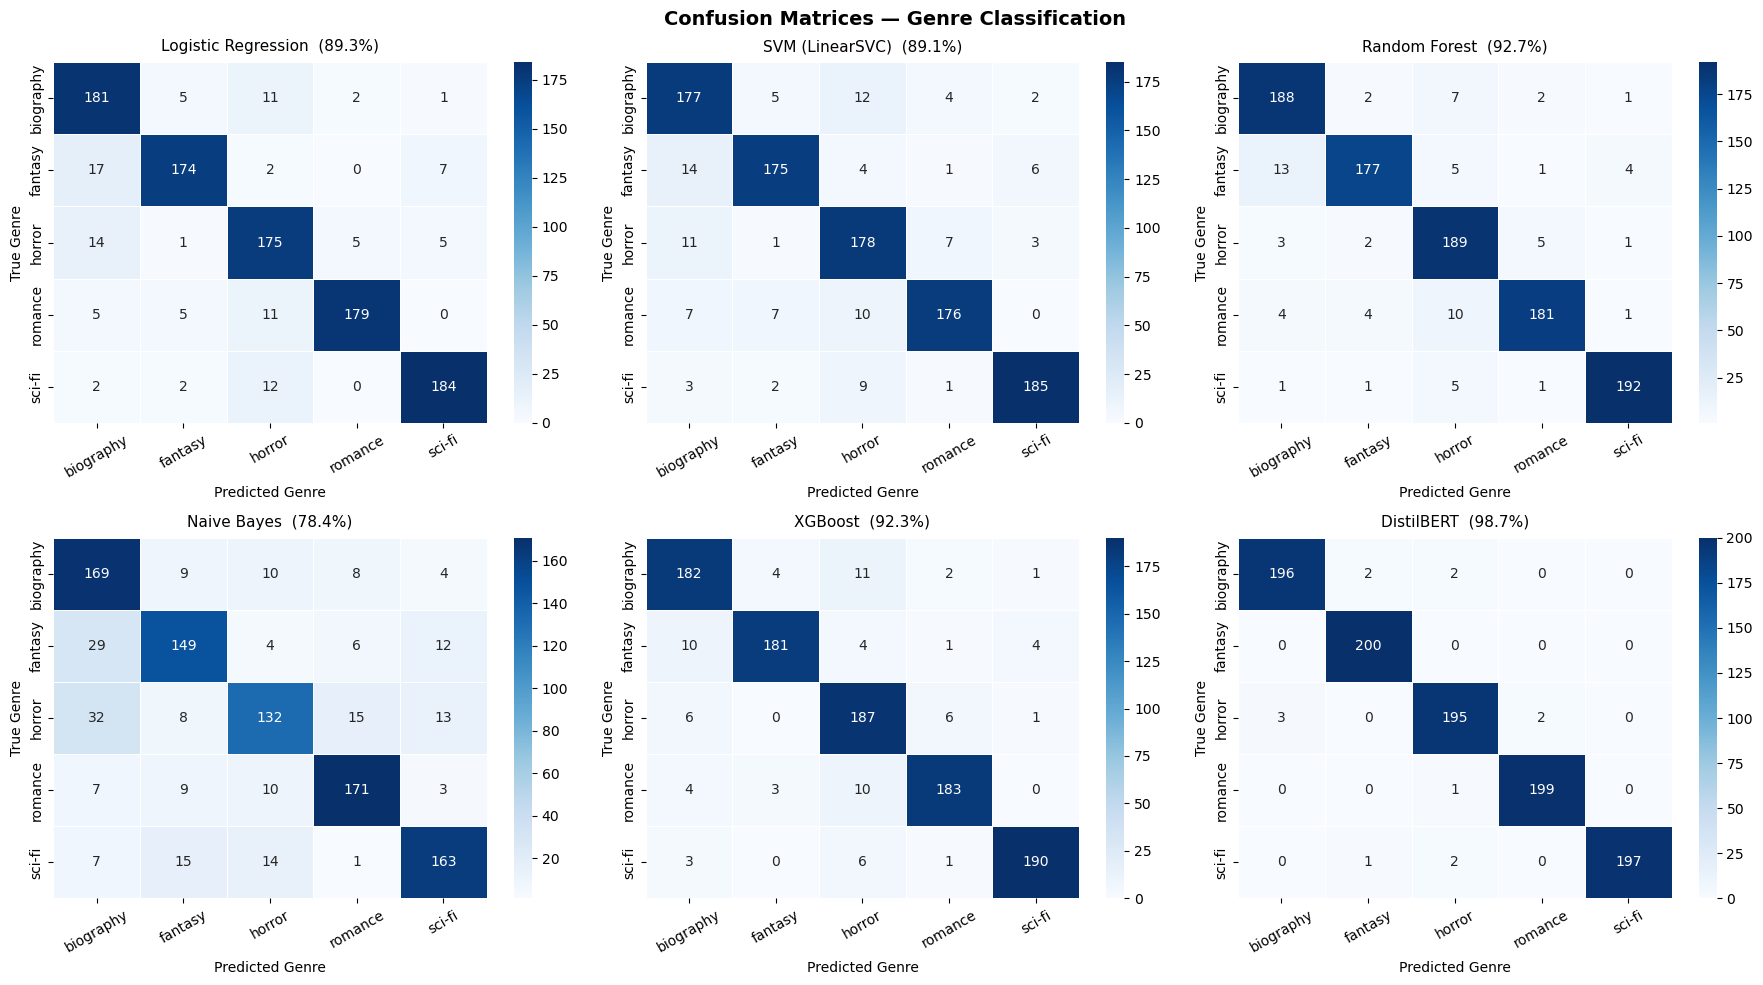

Saved: images/confusion_matrices.png


In [35]:
PREDS = {
    'Logistic Regression': y_pred_lr,
    'SVM (LinearSVC)':     y_pred_svm,
    'Random Forest':       y_pred_rf,
    'Naive Bayes':         y_pred_nb,
    'XGBoost':             y_pred_xgb,
    'DistilBERT':          y_pred_bert,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (name, y_pred) in zip(axes_flat, PREDS.items()):
    cm = confusion_matrix(y_test, y_pred, labels=GENRES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES,
                linewidths=0.5, ax=ax)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}  ({acc:.1%})', fontsize=11, pad=8)
    ax.set_xlabel('Predicted Genre')
    ax.set_ylabel('True Genre')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Confusion Matrices — Genre Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/confusion_matrices.png')

## Error Analysis
Inspect the actual misclassified partitions to understand *why* genres get confused.

In [36]:
def error_analysis(model_name, y_pred):
    """Print misclassified partitions with their true and predicted genres."""
    # Align predictions back to the original partition rows used in the test split
    test_indices = partitions.index[
        partitions.index.isin(
            partitions.iloc[
                list(range(len(partitions)))
            ].index
        )
    ]

    # Rebuild a results frame from the test split
    _, X_test_raw, _, y_test_raw = train_test_split(
        partitions['text'].values, partitions['genre'].values,
        test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=partitions['genre'].values
    )

    errors = pd.DataFrame({
        'text':      X_test_raw,
        'true':      y_test_raw,
        'predicted': y_pred,
    })
    errors = errors[errors['true'] != errors['predicted']]

    print(f"\n{'='*60}")
    print(f"  {model_name} — {len(errors)} misclassified partitions")
    print(f"{'='*60}")
    print(errors.groupby(['true','predicted']).size().rename('count').to_string())
    print(f"\n--- Sample misclassifications (up to 3 per pair) ---")
    for (true, pred), group in errors.groupby(['true','predicted']):
        for _, row in group.head(3).iterrows():
            print(f"\n[True: {true}] → [Predicted: {pred}]")
            print(f"  {row['text'][:200]}...")

error_analysis("Logistic Regression", y_pred_lr)
error_analysis("SVM", y_pred_svm)



  Logistic Regression — 107 misclassified partitions
true       predicted
biography  fantasy       5
           horror       11
           romance       2
           sci-fi        1
fantasy    biography    17
           horror        2
           sci-fi        7
horror     biography    14
           fantasy       1
           romance       5
           sci-fi        5
romance    biography     5
           fantasy       5
           horror       11
sci-fi     biography     2
           fantasy       2
           horror       12

--- Sample misclassifications (up to 3 per pair) ---

[True: biography] → [Predicted: fantasy]
  prospect remain'd of the Meredith's fulfilling their part of our agreement, because I thought myself under great obligations to them for what they had done, and would do if they could; but, if they fi...

[True: biography] → [Predicted: fantasy]
  shining; but as they listened they plainly heard the tinkling of many drops falling through the forest, and sliding from

## Vocabulary Coverage
How much of the 1,109-word genre vocabulary does each genre actually use — and does the test split cover similar ground to training?

- **Left chart** — cumulative coverage: the fraction of the full vocabulary that appears at least once *somewhere* across all partitions of a genre. High coverage means the model has many signal words to work with; low coverage means much of the vocabulary was never seen for that genre.
- **Right chart** — per-partition coverage: for a single 400-word partition, what fraction of vocabulary words appear? The distribution shows the range a model typically encounters at inference time.

A large train–test gap in either chart would indicate the test books use substantially different vocabulary, which reduces how much TF-IDF signal the models can exploit.

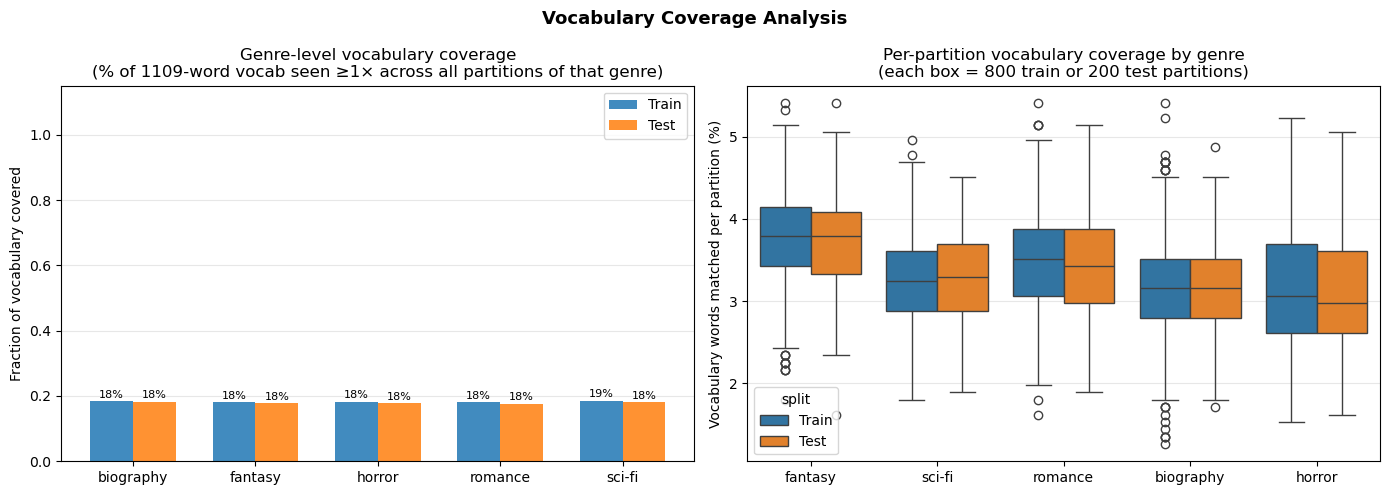

Saved: images/vocabulary_coverage.png

Genre-level coverage summary:
Genre           Train     Test      Gap
--------------------------------------
biography       18.4%    18.3%    +0.1%
fantasy         18.2%    17.8%    +0.5%
horror          18.3%    17.9%    +0.5%
romance         18.2%    17.7%    +0.5%
sci-fi          18.6%    18.2%    +0.4%


In [37]:
# ── Vocabulary Coverage Analysis ────────────────────────────────────────────
vocab_size = len(vocabulary)

def genre_vocab_coverage(X_split, y_split):
    """Fraction of vocabulary words that appear ≥1× across all partitions of each genre."""
    result = {}
    y_arr = np.array(y_split)
    for genre in GENRES:
        X_g = X_split[y_arr == genre]
        # count columns with at least one non-zero entry across all genre partitions
        n_covered = int(np.asarray((X_g > 0).sum(axis=0) > 0).flatten().sum())
        result[genre] = n_covered / vocab_size
    return result

train_genre_cov = genre_vocab_coverage(X_train, y_train)
test_genre_cov  = genre_vocab_coverage(X_test,  y_test)

# Per-partition: how many vocab words are matched in each individual partition (as %)
train_part_cov = np.asarray((X_train > 0).sum(axis=1)).flatten() / vocab_size * 100
test_part_cov  = np.asarray((X_test  > 0).sum(axis=1)).flatten() / vocab_size * 100

train_cov_df = pd.DataFrame({'genre': y_train, 'coverage': train_part_cov, 'split': 'Train'})
test_cov_df  = pd.DataFrame({'genre': y_test,  'coverage': test_part_cov,  'split': 'Test'})
cov_df = pd.concat([train_cov_df, test_cov_df], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative genre-level coverage
x, width = np.arange(len(GENRES)), 0.35
ax = axes[0]
bars_tr = ax.bar(x - width/2, [train_genre_cov[g] for g in GENRES], width,
                 label='Train', color='#1f77b4', alpha=0.85)
bars_te = ax.bar(x + width/2, [test_genre_cov[g]  for g in GENRES], width,
                 label='Test',  color='#ff7f0e', alpha=0.85)
for bar, g in zip(bars_tr, GENRES):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{train_genre_cov[g]:.0%}", ha='center', fontsize=8)
for bar, g in zip(bars_te, GENRES):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{test_genre_cov[g]:.0%}", ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(GENRES)
ax.set_ylabel('Fraction of vocabulary covered')
ax.set_ylim(0, 1.15)
ax.set_title(f'Genre-level vocabulary coverage\n(% of {vocab_size}-word vocab seen ≥1× across all partitions of that genre)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: per-partition vocabulary coverage distribution
sns.boxplot(data=cov_df, x='genre', y='coverage', hue='split',
            palette={'Train': '#1f77b4', 'Test': '#ff7f0e'}, ax=axes[1])
axes[1].set_ylabel('Vocabulary words matched per partition (%)')
axes[1].set_title('Per-partition vocabulary coverage by genre\n(each box = 800 train or 200 test partitions)')
axes[1].set_xlabel('')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Vocabulary Coverage Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/vocabulary_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/vocabulary_coverage.png')

print("\nGenre-level coverage summary:")
print(f"{'Genre':12} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("-" * 38)
for g in GENRES:
    gap = train_genre_cov[g] - test_genre_cov[g]
    print(f"{g:12} {train_genre_cov[g]:>8.1%} {test_genre_cov[g]:>8.1%} {gap:>+8.1%}")

## Inter-Genre Vocabulary Overlap
Not all vocabulary words are equally useful. A word that appears in horror, fantasy, *and* sci-fi training books carries almost no discriminative signal — the model can't use it to tell those genres apart.

- **Left heatmap** — Jaccard similarity between each pair of genres' vocabulary sets (how many words they share relative to their combined set), with the raw shared word count in brackets. High values mean two genres use mostly the same vocabulary, making them inherently harder to separate.
- **Right chart** — word discriminability: how many of the 1,109 vocabulary words appear in exactly 1 genre (exclusive, strong signal), 2–4 genres (partially shared), or all 5 (pure noise for TF-IDF). The more words in the rightmost bars, the noisier the vocabulary.

Genre pairs with high Jaccard overlap here will reliably appear as confusion pairs in the confusion matrices — this is a structural property of the vocabulary, not a model weakness.

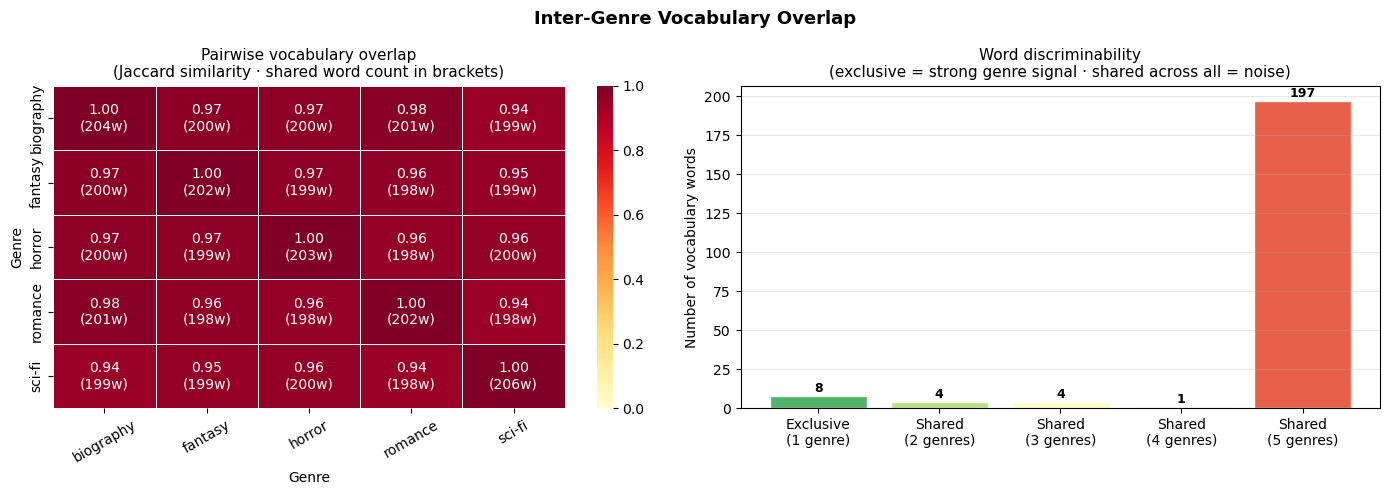

Saved: images/vocab_genre_overlap.png

Genre vocabulary sizes (training set):
  biography   :  204 / 1109 words covered
  fantasy     :  202 / 1109 words covered
  horror      :  203 / 1109 words covered
  romance     :  202 / 1109 words covered
  sci-fi      :  206 / 1109 words covered

Word discriminability breakdown:
     8 words exclusive to 1 genre (0.7% of vocabulary)
     4 words shared across 2 genres (0.4% of vocabulary)
     4 words shared across 3 genres (0.4% of vocabulary)
     1 words shared across 4 genres (0.1% of vocabulary)
   197 words shared across 5 genres (17.8% of vocabulary)

  Words in ALL 5 genres (197): across, air, also, always, among, another, answered, asked, away, back, beautiful, began, better, black, british, called, came, cannot, captain, child, children, come, could, count, country, cried, day, days, dead, dear, death, done, door, empire, england, enough, even, ever, every, eyes, face, far, father, fear, feet, fell, felt, find, first, following, found

In [38]:
# ── Inter-Genre Vocabulary Overlap ───────────────────────────────────────────
# For each genre, find which vocabulary words appear in its training partitions
genre_word_sets = {}
for genre in GENRES:
    col_sums = np.asarray(X_train[np.array(y_train) == genre].sum(axis=0)).flatten()
    genre_word_sets[genre] = set(np.where(col_sums > 0)[0].tolist())

# Pairwise absolute overlap count and Jaccard similarity
n = len(GENRES)
overlap_count   = np.zeros((n, n), dtype=int)
overlap_jaccard = np.zeros((n, n))
for i, g1 in enumerate(GENRES):
    for j, g2 in enumerate(GENRES):
        inter = len(genre_word_sets[g1] & genre_word_sets[g2])
        union = len(genre_word_sets[g1] | genre_word_sets[g2])
        overlap_count[i, j]   = inter
        overlap_jaccard[i, j] = inter / union if union else 0.0

# Word discriminability: how many genres does each vocabulary word appear in?
word_genre_count = np.zeros(vocab_size, dtype=int)
for ws in genre_word_sets.values():
    for idx in ws:
        word_genre_count[idx] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Jaccard heatmap annotated with both Jaccard and raw word count
annot = np.array([[f'{overlap_jaccard[i,j]:.2f}\n({overlap_count[i,j]}w)'
                   for j in range(n)] for i in range(n)])
sns.heatmap(overlap_jaccard, annot=annot, fmt='', cmap='YlOrRd',
            xticklabels=GENRES, yticklabels=GENRES,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Pairwise vocabulary overlap\n(Jaccard similarity · shared word count in brackets)', fontsize=11)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Genre')
axes[0].tick_params(axis='x', rotation=30)

# Right: word discriminability — how many genres each word appears in
disc = [(k, int((word_genre_count == k).sum())) for k in range(1, n + 1)]
disc = [(k, c) for k, c in disc if c > 0]
ks, cs = zip(*disc)
bar_colors = plt.cm.RdYlGn(np.linspace(0.85, 0.15, len(ks)))
bars = axes[1].bar(range(len(ks)), cs, color=bar_colors, edgecolor='white', alpha=0.9)
for bar, c in zip(bars, cs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(c), ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(ks)))
axes[1].set_xticklabels(['Exclusive\n(1 genre)' if k == 1 else f'Shared\n({k} genres)' for k in ks])
axes[1].set_ylabel('Number of vocabulary words')
axes[1].set_title('Word discriminability\n(exclusive = strong genre signal · shared across all = noise)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Inter-Genre Vocabulary Overlap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/vocab_genre_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/vocab_genre_overlap.png')

print(f"\nGenre vocabulary sizes (training set):")
for g in GENRES:
    print(f"  {g:12}: {len(genre_word_sets[g]):4d} / {vocab_size} words covered")

print(f"\nWord discriminability breakdown:")
for k, c in disc:
    label = "exclusive to 1 genre" if k == 1 else f"shared across {k} genres"
    print(f"  {c:4d} words {label} ({c/vocab_size:.1%} of vocabulary)")

words_in_all = [vocabulary[i] for i, cnt in enumerate(word_genre_count) if cnt == n]
if words_in_all:
    print(f"\n  Words in ALL {n} genres ({len(words_in_all)}): {', '.join(words_in_all)}")

## Model Confidence
When a model predicts the wrong genre, is it hesitating or is it confidently wrong?

- **Left chart** — mean max-probability for correct vs incorrect predictions. A large gap means the model "knows when it knows"; a small gap means it predicts all genres with similar certainty regardless of whether it gets them right.
- **Right chart** — full distribution of max probabilities across all 1,000 test partitions. Models pushed to the edges (near 0 or 1) are more decisive; flatter distributions signal hedging.

*SVM (LinearSVC) is excluded because it does not expose calibrated probabilities.*

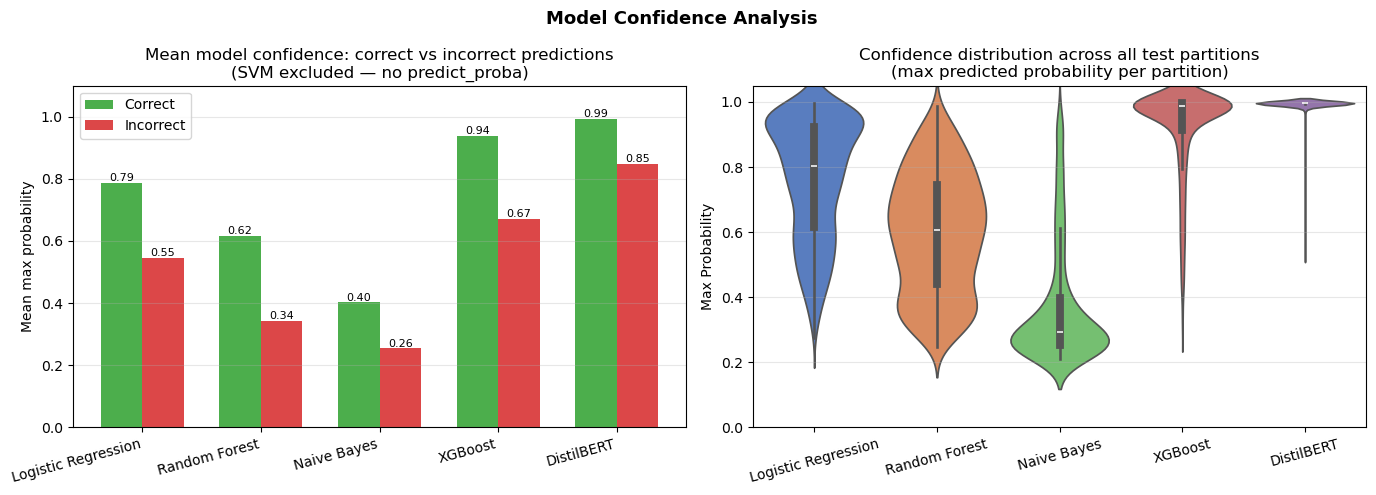

Saved: images/model_confidence.png


In [39]:
# ── Model Confidence Analysis ───────────────────────────────────────────────
# LinearSVC (SVM) excluded — no predict_proba support
PROBA_MODELS = {
    'Logistic Regression': (lr,      X_test, y_test, y_pred_lr),
    'Random Forest':       (rf,      X_test, y_test, y_pred_rf),
    'Naive Bayes':         (nb,      X_test, y_test, y_pred_nb),
    'XGBoost':             (xgb_clf, X_test, y_test, y_pred_xgb),
}

# DistilBERT: softmax the raw logits stored in preds_output
bert_proba    = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
bert_max_prob = bert_proba.max(axis=1)
bert_correct  = np.array(y_pred_bert) == np.array(y_test_bert)

model_labels     = []
mean_conf_corr   = []
mean_conf_incorr = []
conf_rows        = []

for label, (model, X_inp, y_true, y_pred) in PROBA_MODELS.items():
    proba    = model.predict_proba(X_inp)
    max_prob = proba.max(axis=1)
    correct  = np.array(y_pred) == np.array(y_true)
    model_labels.append(label)
    mean_conf_corr.append(max_prob[correct].mean())
    mean_conf_incorr.append(max_prob[~correct].mean() if (~correct).any() else np.nan)
    for p in max_prob:
        conf_rows.append({'Model': label, 'Max Probability': p})

model_labels.append('DistilBERT')
mean_conf_corr.append(bert_max_prob[bert_correct].mean())
mean_conf_incorr.append(bert_max_prob[~bert_correct].mean() if (~bert_correct).any() else np.nan)
for p in bert_max_prob:
    conf_rows.append({'Model': 'DistilBERT', 'Max Probability': p})

conf_df = pd.DataFrame(conf_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean confidence for correct vs incorrect predictions
x, width = np.arange(len(model_labels)), 0.35
ax = axes[0]
bars_c  = ax.bar(x - width/2, mean_conf_corr,   width, label='Correct',   color='#2ca02c', alpha=0.85)
bars_ic = ax.bar(x + width/2, mean_conf_incorr, width, label='Incorrect', color='#d62728', alpha=0.85)
for bar, v in zip(bars_c, mean_conf_corr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.2f}', ha='center', fontsize=8)
for bar, v in zip(bars_ic, mean_conf_incorr):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha='right')
ax.set_ylabel('Mean max probability')
ax.set_ylim(0, 1.1)
ax.set_title('Mean model confidence: correct vs incorrect predictions\n(SVM excluded — no predict_proba)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: full confidence distribution per model
sns.violinplot(data=conf_df, x='Model', y='Max Probability', ax=axes[1],
               palette='muted', inner='box')
axes[1].set_title('Confidence distribution across all test partitions\n(max predicted probability per partition)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Model Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/model_confidence.png')

## Save Trained Models
Serialises both models and the vectorizer so they can be loaded without re-training.

In [40]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(lr,         'models/model_logistic_regression.pkl')
joblib.dump(svm,        'models/model_svm.pkl')
joblib.dump(rf,         'models/model_random_forest.pkl')
joblib.dump(nb,         'models/model_naive_bayes.pkl')
joblib.dump(xgb_clf,    'models/model_xgboost.pkl')
joblib.dump(vectorizer, 'FeatureTrainingData/vectorizer.pkl')
model_bert.save_pretrained('models/model_distilbert')
tokenizer_bert.save_pretrained('models/model_distilbert')
print("Saved: models/model_logistic_regression.pkl")
print("Saved: models/model_svm.pkl")
print("Saved: models/model_random_forest.pkl")
print("Saved: models/model_naive_bayes.pkl")
print("Saved: models/model_xgboost.pkl")
print("Saved: FeatureTrainingData/vectorizer.pkl")
print("Saved: models/model_distilbert/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: models/model_logistic_regression.pkl
Saved: models/model_svm.pkl
Saved: models/model_random_forest.pkl
Saved: models/model_naive_bayes.pkl
Saved: models/model_xgboost.pkl
Saved: FeatureTrainingData/vectorizer.pkl
Saved: models/model_distilbert/


## Quick Predict on New Text
Load the saved models and classify an arbitrary passage.

In [41]:
from bert_wrapper import DistilBertGenreClassifier

vec      = joblib.load('FeatureTrainingData/vectorizer.pkl')
lr2      = joblib.load('models/model_logistic_regression.pkl')
svm2     = joblib.load('models/model_svm.pkl')
rf2      = joblib.load('models/model_random_forest.pkl')
nb2      = joblib.load('models/model_naive_bayes.pkl')
xgb2     = joblib.load('models/model_xgboost.pkl')
bert_clf = DistilBertGenreClassifier('models/model_distilbert')

sample_text = [
    "The robot spaceship launched into the dark void of deep space as the crew "
    "prepared for their mission to the distant star system far beyond the galaxy."
]

X_sample = vec.transform(sample_text)
for name, model in [('LR', lr2), ('SVM', svm2), ('RF', rf2), ('NB', nb2), ('XGBoost', xgb2)]:
    print(f"{name:12}: {model.predict(X_sample)[0]}")
print(f"{'DistilBERT':12}: {bert_clf.predict(sample_text)[0]}")

probs = pd.Series(lr2.predict_proba(X_sample)[0], index=lr2.classes_)
print(f"\nLR class probabilities:")
print(probs.sort_values(ascending=False).to_string())

LR          : sci-fi
SVM         : sci-fi
RF          : sci-fi
NB          : sci-fi
XGBoost     : sci-fi


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT  : sci-fi

LR class probabilities:
sci-fi       0.932356
horror       0.044236
biography    0.012012
romance      0.010180
fantasy      0.001216
